In [3]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.datasets import make_blobs

In [4]:
x, y = make_blobs(n_samples=500, n_features=2, centers=5, random_state=3)

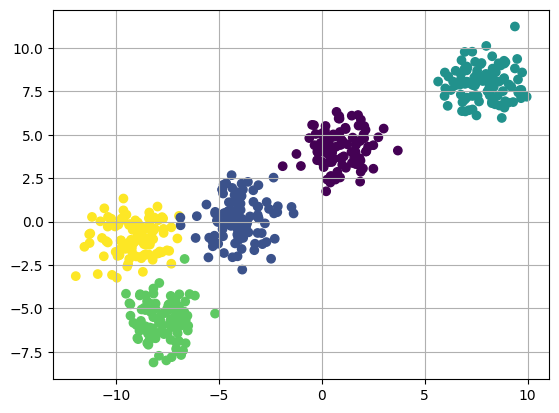

In [5]:
fig = plt.figure(0)
plt.grid(True)
plt.scatter(x[:,0],x[:,1], c=y)

Initialise Centres

In [6]:
k = 5
colors = ['green', 'yellow', 'blue', 'cyan', 'red']
clusters = {}

In [28]:
for i in range (k):
    center = 10*(2*np.random.random((x.shape[1]))-1)
    points = []
    cluster = {
        'center' : center,
        'points' : [],
        'color' : colors[i]
    }
    clusters[i] = cluster

In [29]:
clusters

{0: {'center': array([-3.79249885, -2.53061685]),
  'points': [],
  'color': 'green'},
 1: {'center': array([-4.71742546, -8.4011624 ]),
  'points': [],
  'color': 'yellow'},
 2: {'center': array([-5.69439359,  3.78281208]),
  'points': [],
  'color': 'blue'},
 3: {'center': array([-8.3992133 ,  5.21088192]),
  'points': [],
  'color': 'cyan'},
 4: {'center': array([ 8.39554427, -3.82717214]),
  'points': [],
  'color': 'red'}}

<function matplotlib.pyplot.show(close=None, block=None)>

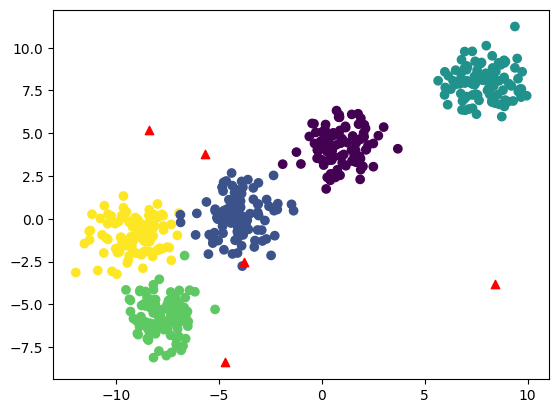

In [30]:
plt.scatter(x[:,0], x[:,1], c=y)
for i in clusters:
    center = clusters[i]['center']
    plt.scatter(center[0],center[1], marker='^', c='red')
plt.show

E step

In [50]:
def distance(v1, v2):
    return np.sqrt(np.sum((v1-v2)**2))

def assign_clusters():
    for i in range(x.shape[0]):
        dist = []
        curr_x = x[i]
        for i in range(k):
            dist.append(distance(curr_x,clusters[i]['center']))
        curr_cluster = np.argmin(dist)
        clusters[curr_cluster]['points'].append(curr_x)

M step - Plotting Clusters

In [53]:
def plot_clusters():
    for i in clusters:
        pts =np.array(clusters[i]['points'])
        try:
            plt.scatter(pts[:,0],pts[:,1],c=clusters[i]['color'])
        except:
            pass
        centre = clusters[i]['center']
        plt.scatter(centre[0],centre[1], c='black', marker ='^')

In [49]:
def update_clusters():
    for i in range (k):
        pts = np.array(clusters[i]['points'])
        try:
            new_center = np.mean(pts, axis=0)
            clusters[i]['center'] = new_center
            clusters[i]['points'] = []
        except:
            pass

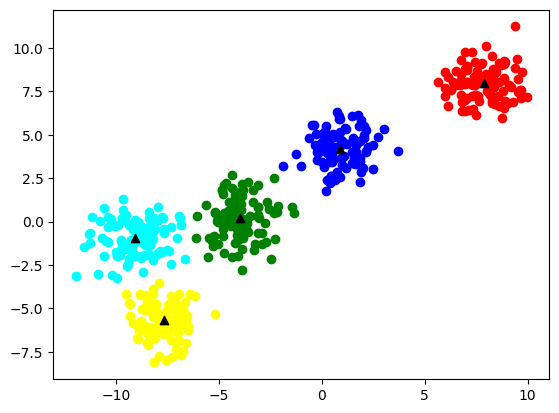

In [58]:
assign_clusters()
plot_clusters()
update_clusters()

Scikit Learn K - Means

In [59]:
from sklearn.cluster import KMeans

In [62]:
km = KMeans(n_clusters=5)

In [60]:
x, y = make_blobs(n_samples=500, n_features=2, centers=5, random_state=3)

In [64]:
km.fit(x,y) # computes the centres

c:\Users\sudhir\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(n_clusters=5)

In [67]:
centres=km.cluster_centers_

In [69]:
labels = km.labels_

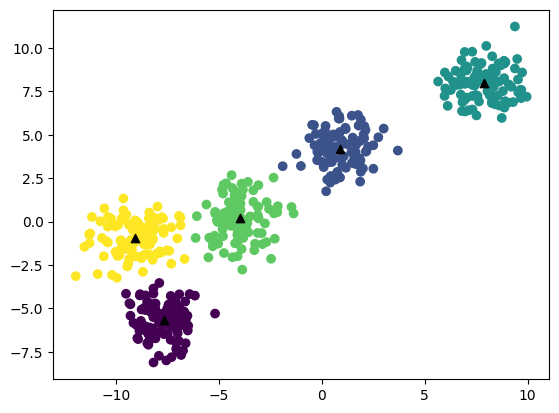

In [74]:
plt.scatter(x[:,0],x[:,1], c=labels)
plt.scatter(centres[:,0],centres[:,1], c='black', marker='^')